# Análisis Exploratorio — International Football Results (1872–2026)

Respondemos preguntas concretas sobre 153 años de fútbol internacional.
Cada sección parte de una pregunta, muestra los datos y concluye con 
un hallazgo explícito.

**Datos:** `data/processed/results_clean.csv` (49,477 partidos)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo visual consistente en todo el notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (10, 5)

# Cargar datos limpios
df = pd.read_csv('../data/processed/results_clean.csv', parse_dates=['date'])

print(f"✅ {len(df):,} partidos cargados ({df['year'].min()}–{df['year'].max()})")
print(f"   Columnas: {list(df.columns)}")

✅ 49,477 partidos cargados (1872–2026)
   Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'year', 'decade', 'result']


## 1. ¿Cuánto vale ser local?

El equipo local tiene ventajas reales: juega en su estadio, 
con su afición, sin viaje previo. Pero ¿cuánto se traduce 
eso en resultados? ¿Y cambia si el partido es en cancha neutral?

In [2]:
# Separamos partidos en cancha propia vs cancha neutral
local_real    = df[df['neutral'] == False]
cancha_neutra = df[df['neutral'] == True]

def pct_resultados(subset):
    conteo = subset['result'].value_counts()
    total  = len(subset)
    return {
        'Local gana':    conteo.get('home_win', 0) / total * 100,
        'Empate':        conteo.get('draw',     0) / total * 100,
        'Visitante gana':conteo.get('away_win', 0) / total * 100,
        'n': total
    }

stats_local   = pct_resultados(local_real)
stats_neutral = pct_resultados(cancha_neutra)

print("En cancha propia:")
print(f"  Local gana:     {stats_local['Local gana']:.1f}%")
print(f"  Empate:         {stats_local['Empate']:.1f}%")
print(f"  Visitante gana: {stats_local['Visitante gana']:.1f}%")
print(f"  (n = {stats_local['n']:,} partidos)\n")

print("En cancha neutral:")
print(f"  Local gana:     {stats_neutral['Local gana']:.1f}%")
print(f"  Empate:         {stats_neutral['Empate']:.1f}%")
print(f"  Visitante gana: {stats_neutral['Visitante gana']:.1f}%")
print(f"  (n = {stats_neutral['n']:,} partidos)")

En cancha propia:
  Local gana:     50.7%
  Empate:         22.9%
  Visitante gana: 26.4%
  (n = 36,356 partidos)

En cancha neutral:
  Local gana:     44.2%
  Empate:         22.4%
  Visitante gana: 33.4%
  (n = 13,121 partidos)


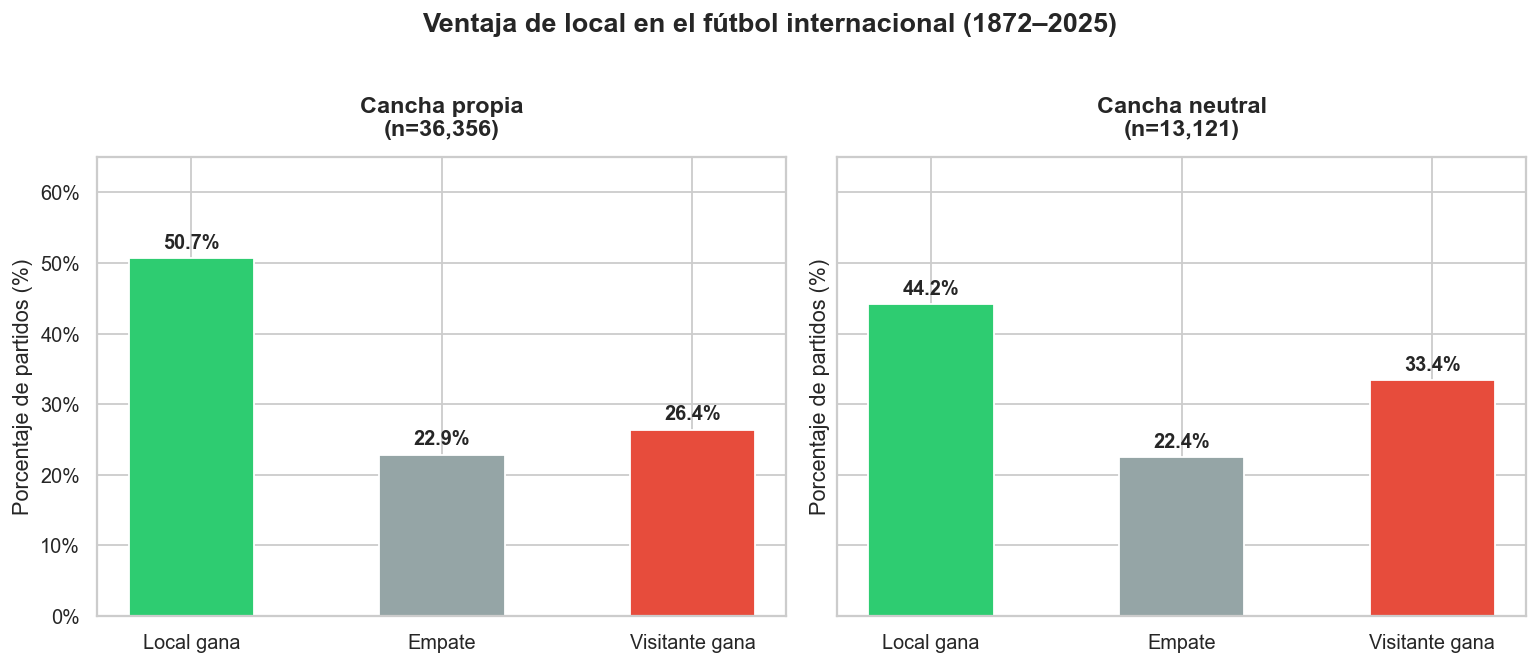

✅ Guardada en reports/figures/


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

categorias = ['Local gana', 'Empate', 'Visitante gana']
colores    = ['#2ecc71', '#95a5a6', '#e74c3c']

for ax, (stats, titulo) in zip(axes, [
    (stats_local,   f"Cancha propia\n(n={stats_local['n']:,})"),
    (stats_neutral, f"Cancha neutral\n(n={stats_neutral['n']:,})")
]):
    valores = [stats[c] for c in categorias]
    barras  = ax.bar(categorias, valores, color=colores, width=0.5, edgecolor='white')

    # Etiqueta de porcentaje encima de cada barra
    for barra, val in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.8,
            f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11
        )

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Porcentaje de partidos (%)')
    ax.set_ylim(0, 65)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

fig.suptitle('Ventaja de local en el fútbol internacional (1872–2025)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/01_ventaja_local.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Guardada en reports/figures/")

### Hallazgo 1

Jugar en cancha propia vale aproximadamente **6.5 puntos porcentuales** 
de ventaja en tasa de victoria (50.7% → 44.2% en neutral). El efecto 
más visible no es que el local gane más empates, sino que el visitante 
pierde menos cuando la cancha es neutral (26.4% → 33.4%).

En 153 años de fútbol internacional, la localía sigue siendo 
uno de los factores más consistentes y medibles.

## 2. ¿Cómo evolucionaron los goles por partido a lo largo de las décadas?

El fútbol de 1920 no se juega igual que el de 2000. Tácticas, 
físico, reglas — todo cambia. ¿Se refleja eso en los goles?

In [4]:
# Promedio de goles totales por partido, agrupado por década
df['total_goles'] = df['home_score'] + df['away_score']

goles_decada = (
    df.groupby('decade')['total_goles']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'promedio_goles', 'count': 'partidos'})
)

# Solo décadas con suficientes partidos (al menos 50)
goles_decada = goles_decada[goles_decada['partidos'] >= 50]

print(goles_decada.to_string(index=False))

 decade  promedio_goles  partidos
   1880        5.581818        55
   1890        5.152542        59
   1900        4.159420       138
   1910        4.218182       330
   1920        3.884477       831
   1930        4.318814      1079
   1940        4.344538       833
   1950        4.004240      1651
   1960        3.478963      2971
   1970        2.974837      4133
   1980        2.526766      5025
   1990        2.778946      6944
   2000        2.801386      9526
   2010        2.738429      9787
   2020        2.713700      6102


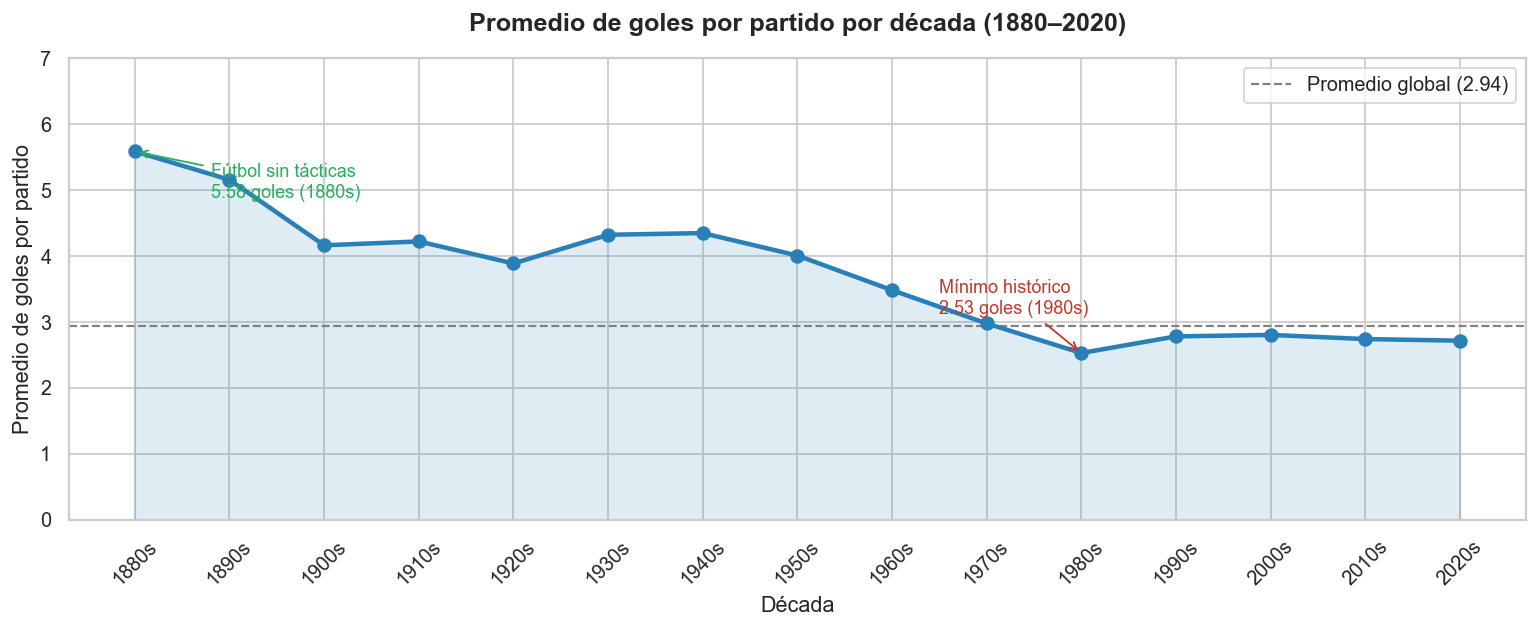

✅ Guardada en reports/figures/


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

# Línea principal
ax.plot(
    goles_decada['decade'],
    goles_decada['promedio_goles'],
    color='#2980b9', linewidth=2.5, marker='o', markersize=7, zorder=3
)

# Área sombreada bajo la línea
ax.fill_between(
    goles_decada['decade'],
    goles_decada['promedio_goles'],
    alpha=0.15, color='#2980b9'
)

# Línea de referencia: promedio global
promedio_global = df['total_goles'].mean()
ax.axhline(promedio_global, color='gray', linestyle='--',
           linewidth=1.2, label=f'Promedio global ({promedio_global:.2f})')

# Anotación del punto mínimo (1980s)
min_row = goles_decada.loc[goles_decada['promedio_goles'].idxmin()]
ax.annotate(
    f"Mínimo histórico\n{min_row['promedio_goles']:.2f} goles ({int(min_row['decade'])}s)",
    xy=(min_row['decade'], min_row['promedio_goles']),
    xytext=(min_row['decade'] - 15, min_row['promedio_goles'] + 0.6),
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    fontsize=10, color='#c0392b'
)

# Anotación del punto máximo (1880s)
max_row = goles_decada.loc[goles_decada['promedio_goles'].idxmax()]
ax.annotate(
    f"Fútbol sin tácticas\n{max_row['promedio_goles']:.2f} goles ({int(max_row['decade'])}s)",
    xy=(max_row['decade'], max_row['promedio_goles']),
    xytext=(max_row['decade'] + 8, max_row['promedio_goles'] - 0.7),
    arrowprops=dict(arrowstyle='->', color='#27ae60'),
    fontsize=10, color='#27ae60'
)

ax.set_title('Promedio de goles por partido por década (1880–2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Década')
ax.set_ylabel('Promedio de goles por partido')
ax.set_xticks(goles_decada['decade'])
ax.set_xticklabels([f"{int(d)}s" for d in goles_decada['decade']], rotation=45)
ax.legend()
ax.set_ylim(0, 7)

plt.tight_layout()
plt.savefig('../reports/figures/02_goles_por_decada.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Guardada en reports/figures/")

### Hallazgo 2

El fútbol del siglo XIX era otro deporte: **5.58 goles por partido** 
en los 1880s, más del doble que hoy. La tendencia descendente es 
constante hasta el **mínimo histórico en los 1980s (2.53 goles)**, 
la era más defensiva del fútbol moderno.

La leve recuperación en los 1990s coincide con el cambio de regla 
del pase hacia atrás (1992): los porteros dejaron de poder tomar 
el balón con la mano en pases de compañero, forzando más juego abierto.

Desde 2000 el promedio se estabiliza alrededor de **2.7 goles**, 
donde permanece hasta hoy.

## 3. ¿Qué selecciones dominan históricamente?

Ranking de selecciones por tasa de victorias, considerando 
solo equipos con volumen suficiente de partidos para que 
el porcentaje sea estadísticamente representativo.

In [6]:
# Construimos estadísticas por equipo
# Cada equipo aparece como local Y como visitante — hay que unificar

# Partidos como local
home = df[['home_team', 'result']].copy()
home.columns = ['team', 'result']
home['fue_local'] = True

# Partidos como visitante
away = df[['away_team', 'result']].copy()
away.columns = ['team', 'result']
away['fue_local'] = False

# Unificamos en una sola tabla
todos = pd.concat([home, away], ignore_index=True)

# Desde la perspectiva de cada equipo, ¿ganó o no?
def gano(row):
    if row['fue_local']:
        return row['result'] == 'home_win'
    else:
        return row['result'] == 'away_win'

todos['gano'] = todos.apply(gano, axis=1)

# Agrupamos por equipo
stats_equipo = (
    todos.groupby('team')
    .agg(
        partidos  = ('gano', 'count'),
        victorias = ('gano', 'sum')
    )
    .reset_index()
)

stats_equipo['tasa_victoria'] = (
    stats_equipo['victorias'] / stats_equipo['partidos'] * 100
)

# Solo equipos con al menos 100 partidos
stats_equipo = stats_equipo[stats_equipo['partidos'] >= 100]

# Top 15
top15 = stats_equipo.nlargest(15, 'tasa_victoria')
print(top15[['team', 'partidos', 'victorias', 'tasa_victoria']].to_string(index=False))

          team  partidos  victorias  tasa_victoria
        Jersey       235        153      65.106383
        Brazil      1062        674      63.465160
      Guernsey       240        145      60.416667
         Spain       786        463      58.905852
       Germany      1034        601      58.123791
       England      1093        627      57.365050
          Iran       615        349      56.747967
     Argentina      1072        595      55.503731
        Tahiti       242        131      54.132231
         Italy       893        477      53.415454
   South Korea      1010        539      53.366337
       Croatia       399        211      52.882206
Czech Republic       363        191      52.617080
   Netherlands       882        455      51.587302
        Russia       749        385      51.401869


### Decisión metodológica: filtrar territorios no-FIFA

Jersey (65.1%) y Guernsey (60.4%) aparecen por encima de Brasil, 
pero compiten en CONIFA contra micronaciones con muy poco desarrollo 
futbolístico. Tahiti y New Caledonia tienen el mismo sesgo en la OFC. 
Su alta tasa refleja la debilidad de sus rivales, no su nivel real.

Se excluyen del ranking final. La decisión queda documentada 
aquí para que sea reproducible y auditada.

In [7]:
# Equipos CONIFA y territorios no-FIFA que distorsionan el ranking
# Su alta tasa refleja la debilidad de sus rivales, no su nivel real
excluir = ['Jersey', 'Guernsey', 'Tahiti', 'Montserrat', 
           'Gibraltar', 'Kosovo', 'Northern Cyprus', 'New Caledonia']

top15_filtrado = (
    stats_equipo[~stats_equipo['team'].isin(excluir)]
    .nlargest(15, 'tasa_victoria')
)

print(top15_filtrado[['team', 'partidos', 'victorias', 'tasa_victoria']].to_string(index=False))

          team  partidos  victorias  tasa_victoria
        Brazil      1062        674      63.465160
         Spain       786        463      58.905852
       Germany      1034        601      58.123791
       England      1093        627      57.365050
          Iran       615        349      56.747967
     Argentina      1072        595      55.503731
         Italy       893        477      53.415454
   South Korea      1010        539      53.366337
       Croatia       399        211      52.882206
Czech Republic       363        191      52.617080
   Netherlands       882        455      51.587302
        Russia       749        385      51.401869
        Mexico      1006        517      51.391650
   Ivory Coast       639        327      51.173709
        France       938        480      51.172708


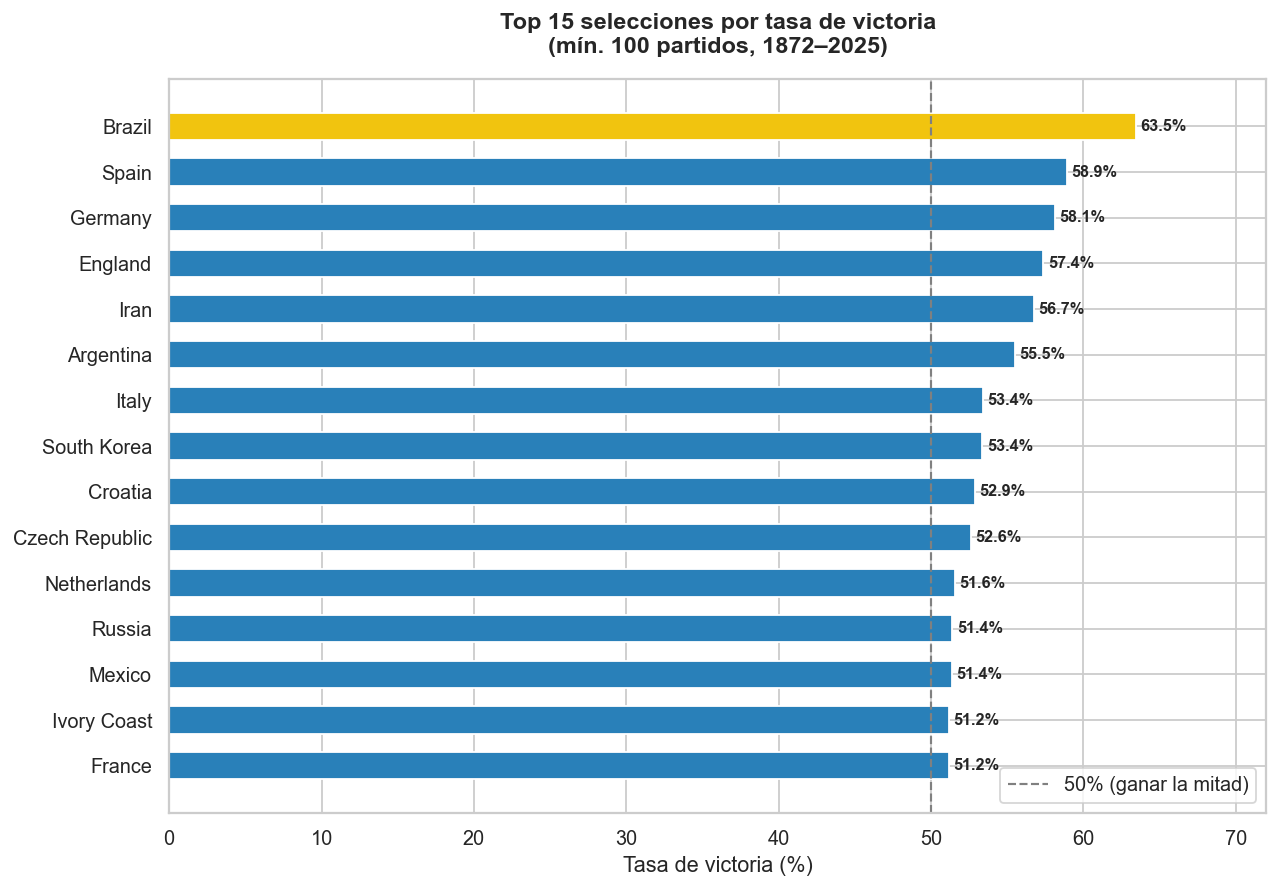

✅ Guardada en reports/figures/


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

colores = ['#f1c40f' if t == 'Brazil' else '#2980b9' 
           for t in top15_filtrado['team']]

barras = ax.barh(
    top15_filtrado['team'],
    top15_filtrado['tasa_victoria'],
    color=colores,
    edgecolor='white',
    height=0.6
)

# Etiqueta de porcentaje al final de cada barra
for barra, val in zip(barras, top15_filtrado['tasa_victoria']):
    ax.text(
        barra.get_width() + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9, fontweight='bold'
    )

# Línea de referencia: 50% (ganar más de la mitad)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.2,
           label='50% (ganar la mitad)')

ax.set_title('Top 15 selecciones por tasa de victoria\n(mín. 100 partidos, 1872–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de victoria (%)')
ax.set_xlim(0, 72)
ax.invert_yaxis()  # El primero arriba
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_top15_selecciones.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Guardada en reports/figures/")

### Hallazgo 3

Brasil lidera con **63.5%** de tasa de victoria en 1,062 partidos — 
una dominancia sostenida a lo largo de más de un siglo. España y 
Alemania están muy parejos en segundo lugar (~58%).

**Nota metodológica:** se excluyeron Jersey, Guernsey, Tahiti y 
New Caledonia del ranking. Aunque sus tasas de victoria superaban 
al resto, compiten principalmente en confederaciones con rivales 
de nivel muy inferior (CONIFA, OFC), lo que distorsiona el 
indicador. El filtro de mínimo 100 partidos elimina el ruido 
estadístico pero no el sesgo de confederación.

Irán en el top 5 (56.7%) es el hallazgo menos esperado — 
refleja una hegemonía regional en Asia que pocas personas asocian 
con esa selección.

## 4. ¿Ha disminuido la ventaja local con el tiempo?

El fútbol moderno tiene viajes más cómodos, estadios neutrales 
más frecuentes y preparación profesional. ¿Ha erosionado eso 
la ventaja de jugar en casa?

In [9]:
# Tasa de victoria local por década (solo cancha propia)
local_tiempo = (
    df[df['neutral'] == False]
    .groupby('decade')['result']
    .apply(lambda x: (x == 'home_win').mean() * 100)
    .reset_index()
    .rename(columns={'result': 'pct_local_gana'})
)

# Solo décadas con suficientes partidos
conteo = df[df['neutral'] == False].groupby('decade').size()
local_tiempo = local_tiempo[local_tiempo['decade'].isin(
    conteo[conteo >= 50].index
)]

print(local_tiempo.to_string(index=False))

 decade  pct_local_gana
   1880       49.090909
   1890       50.000000
   1900       44.360902
   1910       51.186441
   1920       49.656121
   1930       52.289670
   1940       54.407295
   1950       49.347659
   1960       52.240143
   1970       51.475954
   1980       49.077787
   1990       50.572444
   2000       50.899888
   2010       50.539801
   2020       51.083210


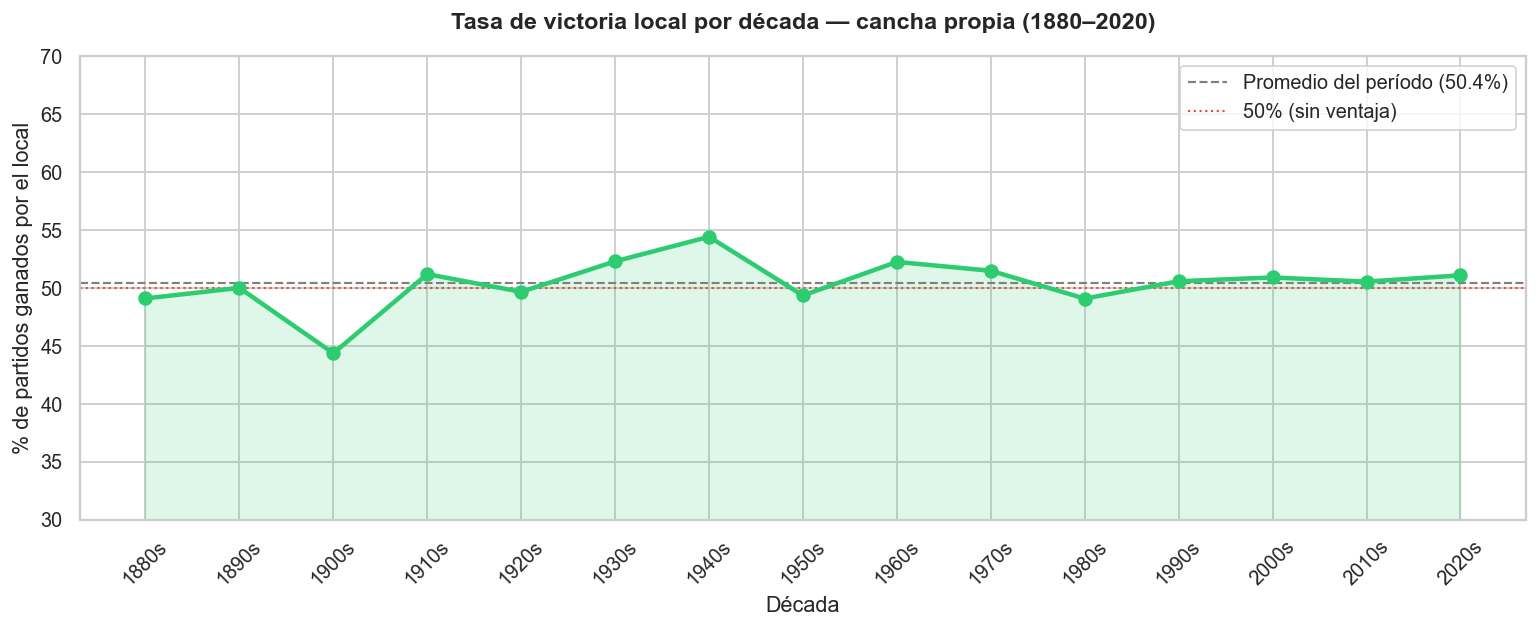

✅ Guardada en reports/figures/


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    local_tiempo['decade'],
    local_tiempo['pct_local_gana'],
    color='#2ecc71', linewidth=2.5, marker='o', markersize=7, zorder=3
)

ax.fill_between(
    local_tiempo['decade'],
    local_tiempo['pct_local_gana'],
    alpha=0.15, color='#2ecc71'
)

# Línea de referencia: promedio del período completo
promedio_local = local_tiempo['pct_local_gana'].mean()
ax.axhline(promedio_local, color='gray', linestyle='--', linewidth=1.2,
           label=f'Promedio del período ({promedio_local:.1f}%)')

# Línea de 50% como referencia de "sin ventaja"
ax.axhline(50, color='#e74c3c', linestyle=':', linewidth=1.2,
           label='50% (sin ventaja)')

ax.set_title('Tasa de victoria local por década — cancha propia (1880–2020)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Década')
ax.set_ylabel('% de partidos ganados por el local')
ax.set_xticks(local_tiempo['decade'])
ax.set_xticklabels([f"{int(d)}s" for d in local_tiempo['decade']], rotation=45)
ax.set_ylim(30, 70)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_ventaja_local_tiempo.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Guardada en reports/figures/")

### Hallazgo 4

La ventaja local es **estructural y persistente** — no ha disminuido 
en 150 años de fútbol. La tasa de victoria local oscila entre 44% y 
54% sin tendencia clara a la baja, incluso en la era moderna con 
viajes cómodos y preparación profesional.

Esto confirma que `neutral` (cancha propia vs neutral) debe ser 
una feature relevante para el modelo predictivo.

## Conclusiones del análisis exploratorio

| # | Pregunta | Hallazgo |
|---|---|---|
| 1 | ¿Cuánto vale ser local? | +6.5pp de tasa de victoria en cancha propia vs neutral |
| 2 | ¿Cómo evolucionaron los goles? | De 5.6 goles/partido en 1880s a 2.7 estables desde 2000 |
| 3 | ¿Qué selecciones dominan? | Brasil lidera (63.5%), seguido de España y Alemania (~58%) |
| 4 | ¿Ha bajado la ventaja local? | No — es estructural y persistente en 150 años |

**Implicaciones para el modelo predictivo:**
- `neutral` es una feature importante
- El dataset está desbalanceado (49% home_win) — accuracy no es la métrica adecuada
- La localía sola ya da una base sólida de predicción